# LeetCode #1125: Smallest Sufficient Team

https://leetcode.com/problems/smallest-sufficient-team/

## Comparison of Approaches

| Approach | Time Complexity | Space Complexity |
| :--- | :--- | :--- |
| **Brute Force (enumerate all subsets of people)** | $O(2^n)$ | $O(2^n)$ |
| **Bitmask DP over skill sets** ★ | $O(2^m \cdot n)$ | $O(2^m)$ |

---

## Understanding the Methods

### Brute Force (enumerate all subsets of people)
Try every subset of the $n$ people, check if they cover all required skills, and keep the smallest valid subset. Enumerating $2^n$ subsets is exponential in the number of people.

### Optimal: Bitmask DP over skill sets ★
Encode the $m$ skills as bits in an integer mask. `dp[mask]` stores the smallest team covering exactly the skills in `mask`. For each person, iterate over all existing DP states and extend them by OR-ing in that person's skill mask. The state space is $2^m$ (skills, not people), and $m \leq 16$, so the table has at most $65{,}536$ entries.

**Why this is better than Brute Force:** With $m \leq 16$ skills the DP table has $2^{16} = 65{,}536$ states — compared to $2^{60}$ subsets if optimizing over 60 people.

**Constraints:**
* `1 <= req_skills.length <= 16`
* `1 <= people.length <= 60`
* `1 <= people[i].length <= 16`
* All strings consist of lowercase English letters

## Solutions

### C#

In [ ]:
public int[] SmallestSufficientTeam(string[] reqSkills, IList<IList<string>> people) {
    // Map each skill to a bit index for compact bitmask representation
    var skillIndex = new Dictionary<string, int>();
    for (int i = 0; i < reqSkills.Length; i++) skillIndex[reqSkills[i]] = i;

    int m = reqSkills.Length;
    int full = (1 << m) - 1;
    // dp[mask] = smallest list of people covering the skills in mask
    var dp = new List<int>[full + 1];
    dp[0] = new List<int>();

    for (int i = 0; i < people.Count; i++) {
        // Build this person's skill bitmask
        int personMask = 0;
        foreach (string skill in people[i]) {
            if (skillIndex.TryGetValue(skill, out int bit)) personMask |= 1 << bit;
        }
        // Extend each reachable DP state by adding this person
        for (int mask = 0; mask <= full; mask++) {
            if (dp[mask] == null) continue;
            int newMask = mask | personMask;
            if (dp[newMask] == null || dp[newMask].Count > dp[mask].Count + 1) {
                dp[newMask] = new List<int>(dp[mask]) { i };
            }
        }
    }
    return dp[full].ToArray();
}

### Python

In [ ]:
def smallestSufficientTeam(self, req_skills: list[str], people: list[list[str]]) -> list[int]:
    # Encode each required skill as a unique bit position
    skill_idx = {s: i for i, s in enumerate(req_skills)}
    m = len(req_skills)
    full = (1 << m) - 1
    # dp[mask] = smallest team (as list of indices) covering all skills in mask
    dp = [None] * (full + 1)
    dp[0] = []
    for i, person in enumerate(people):
        # Compute this person's skill coverage as a bitmask
        person_mask = sum(1 << skill_idx[s] for s in person if s in skill_idx)
        for mask in range(full + 1):
            if dp[mask] is None:
                continue
            new_mask = mask | person_mask
            # Update if adding this person produces a smaller team
            if dp[new_mask] is None or len(dp[new_mask]) > len(dp[mask]) + 1:
                dp[new_mask] = dp[mask] + [i]
    return dp[full]

### Go

In [ ]:
func smallestSufficientTeam(reqSkills []string, people [][]string) []int {
    // Build a skill-to-bit-index map for compact encoding
    skillIdx := make(map[string]int, len(reqSkills))
    for i, s := range reqSkills {
        skillIdx[s] = i
    }
    m := len(reqSkills)
    full := (1 << m) - 1
    dp := make([][]int, full+1)
    dp[0] = []int{}
    for i, person := range people {
        // Compute this person's skill bitmask
        personMask := 0
        for _, s := range person {
            if bit, ok := skillIdx[s]; ok {
                personMask |= 1 << bit
            }
        }
        // Extend all reachable states with this person
        for mask := 0; mask <= full; mask++ {
            if dp[mask] == nil {
                continue
            }
            newMask := mask | personMask
            if dp[newMask] == nil || len(dp[newMask]) > len(dp[mask])+1 {
                team := make([]int, len(dp[mask])+1)
                copy(team, dp[mask])
                team[len(dp[mask])] = i
                dp[newMask] = team
            }
        }
    }
    return dp[full]
}

### Rust

In [ ]:
use std::collections::HashMap;

pub fn smallest_sufficient_team(req_skills: Vec<String>, people: Vec<Vec<String>>) -> Vec<i32> {
    // Map each required skill to a unique bit index
    let skill_idx: HashMap<_, _> = req_skills.iter().enumerate().map(|(i, s)| (s.as_str(), i)).collect();
    let m = req_skills.len();
    let full = (1usize << m) - 1;
    let mut dp: Vec<Option<Vec<i32>>> = vec![None; full + 1];
    dp[0] = Some(vec![]);
    for (i, person) in people.iter().enumerate() {
        // Compute this person's combined skill bitmask
        let person_mask: usize = person.iter()
            .filter_map(|s| skill_idx.get(s.as_str()))
            .fold(0, |m, &b| m | (1 << b));
        for mask in 0..=full {
            if let Some(ref team) = dp[mask].clone() {
                let new_mask = mask | person_mask;
                let new_len = team.len() + 1;
                // Replace only when this path yields a strictly smaller team
                if dp[new_mask].as_ref().map_or(true, |t| t.len() > new_len) {
                    let mut new_team = team.clone();
                    new_team.push(i as i32);
                    dp[new_mask] = Some(new_team);
                }
            }
        }
    }
    dp[full].clone().unwrap()
}

## Example Scenarios

**1. Common Case**
**Input:** req_skills=["java","nodejs","reactjs"], people=[["java"],["nodejs"],["nodejs","reactjs"]]
Skill bits: java=0, nodejs=1, reactjs=2. full=7. dp[0]=[], person 0: dp[1]=[0]. person 1: dp[2]=[1], dp[3]=[0,1]. person 2: dp[6]=[2], dp[7]=[0,2]. Result = **[0, 2]** (persons with java and nodejs+reactjs).

**2. Slightly Complex**
**Input:** req_skills=["algorithms","math","java","reactjs","csharp","aws"], people=[...]
Six skills → $2^6 = 64$ DP states. Algorithm efficiently selects the minimum team by iterating all 64 states per person. Handles combinations unreachable by greedy skill-matching.

**3. Edge Case: Time Factor**
**Input:** 60 people, 16 required skills
Worst case: $60 \times 2^{16} = 60 \times 65{,}536 \approx 3.9 \times 10^6$ operations. All transitions fit within milliseconds since each is a simple bitmask OR and list comparison.

**4. Edge Case: Space Factor**
**Input:** req_skills=["a"], people=[["a"],["a"],["a"]]
One skill, full=1. dp[1] is set on the first person that has skill "a" and never updated (size already 1). Space: $O(2^m \cdot n) = O(2)$ for the DP table entries.

**5. Almost-Impossible but Plausible**
**Input:** 16 skills, 60 people, each person has exactly one skill (no coverage overlap)
Every skill needs exactly one person. The DP must select all 16. If one skill is missing from all people, the DP table entry for `full` remains None — but the problem guarantees a valid team exists. Result size = 16, the maximum possible team.

### Infographic

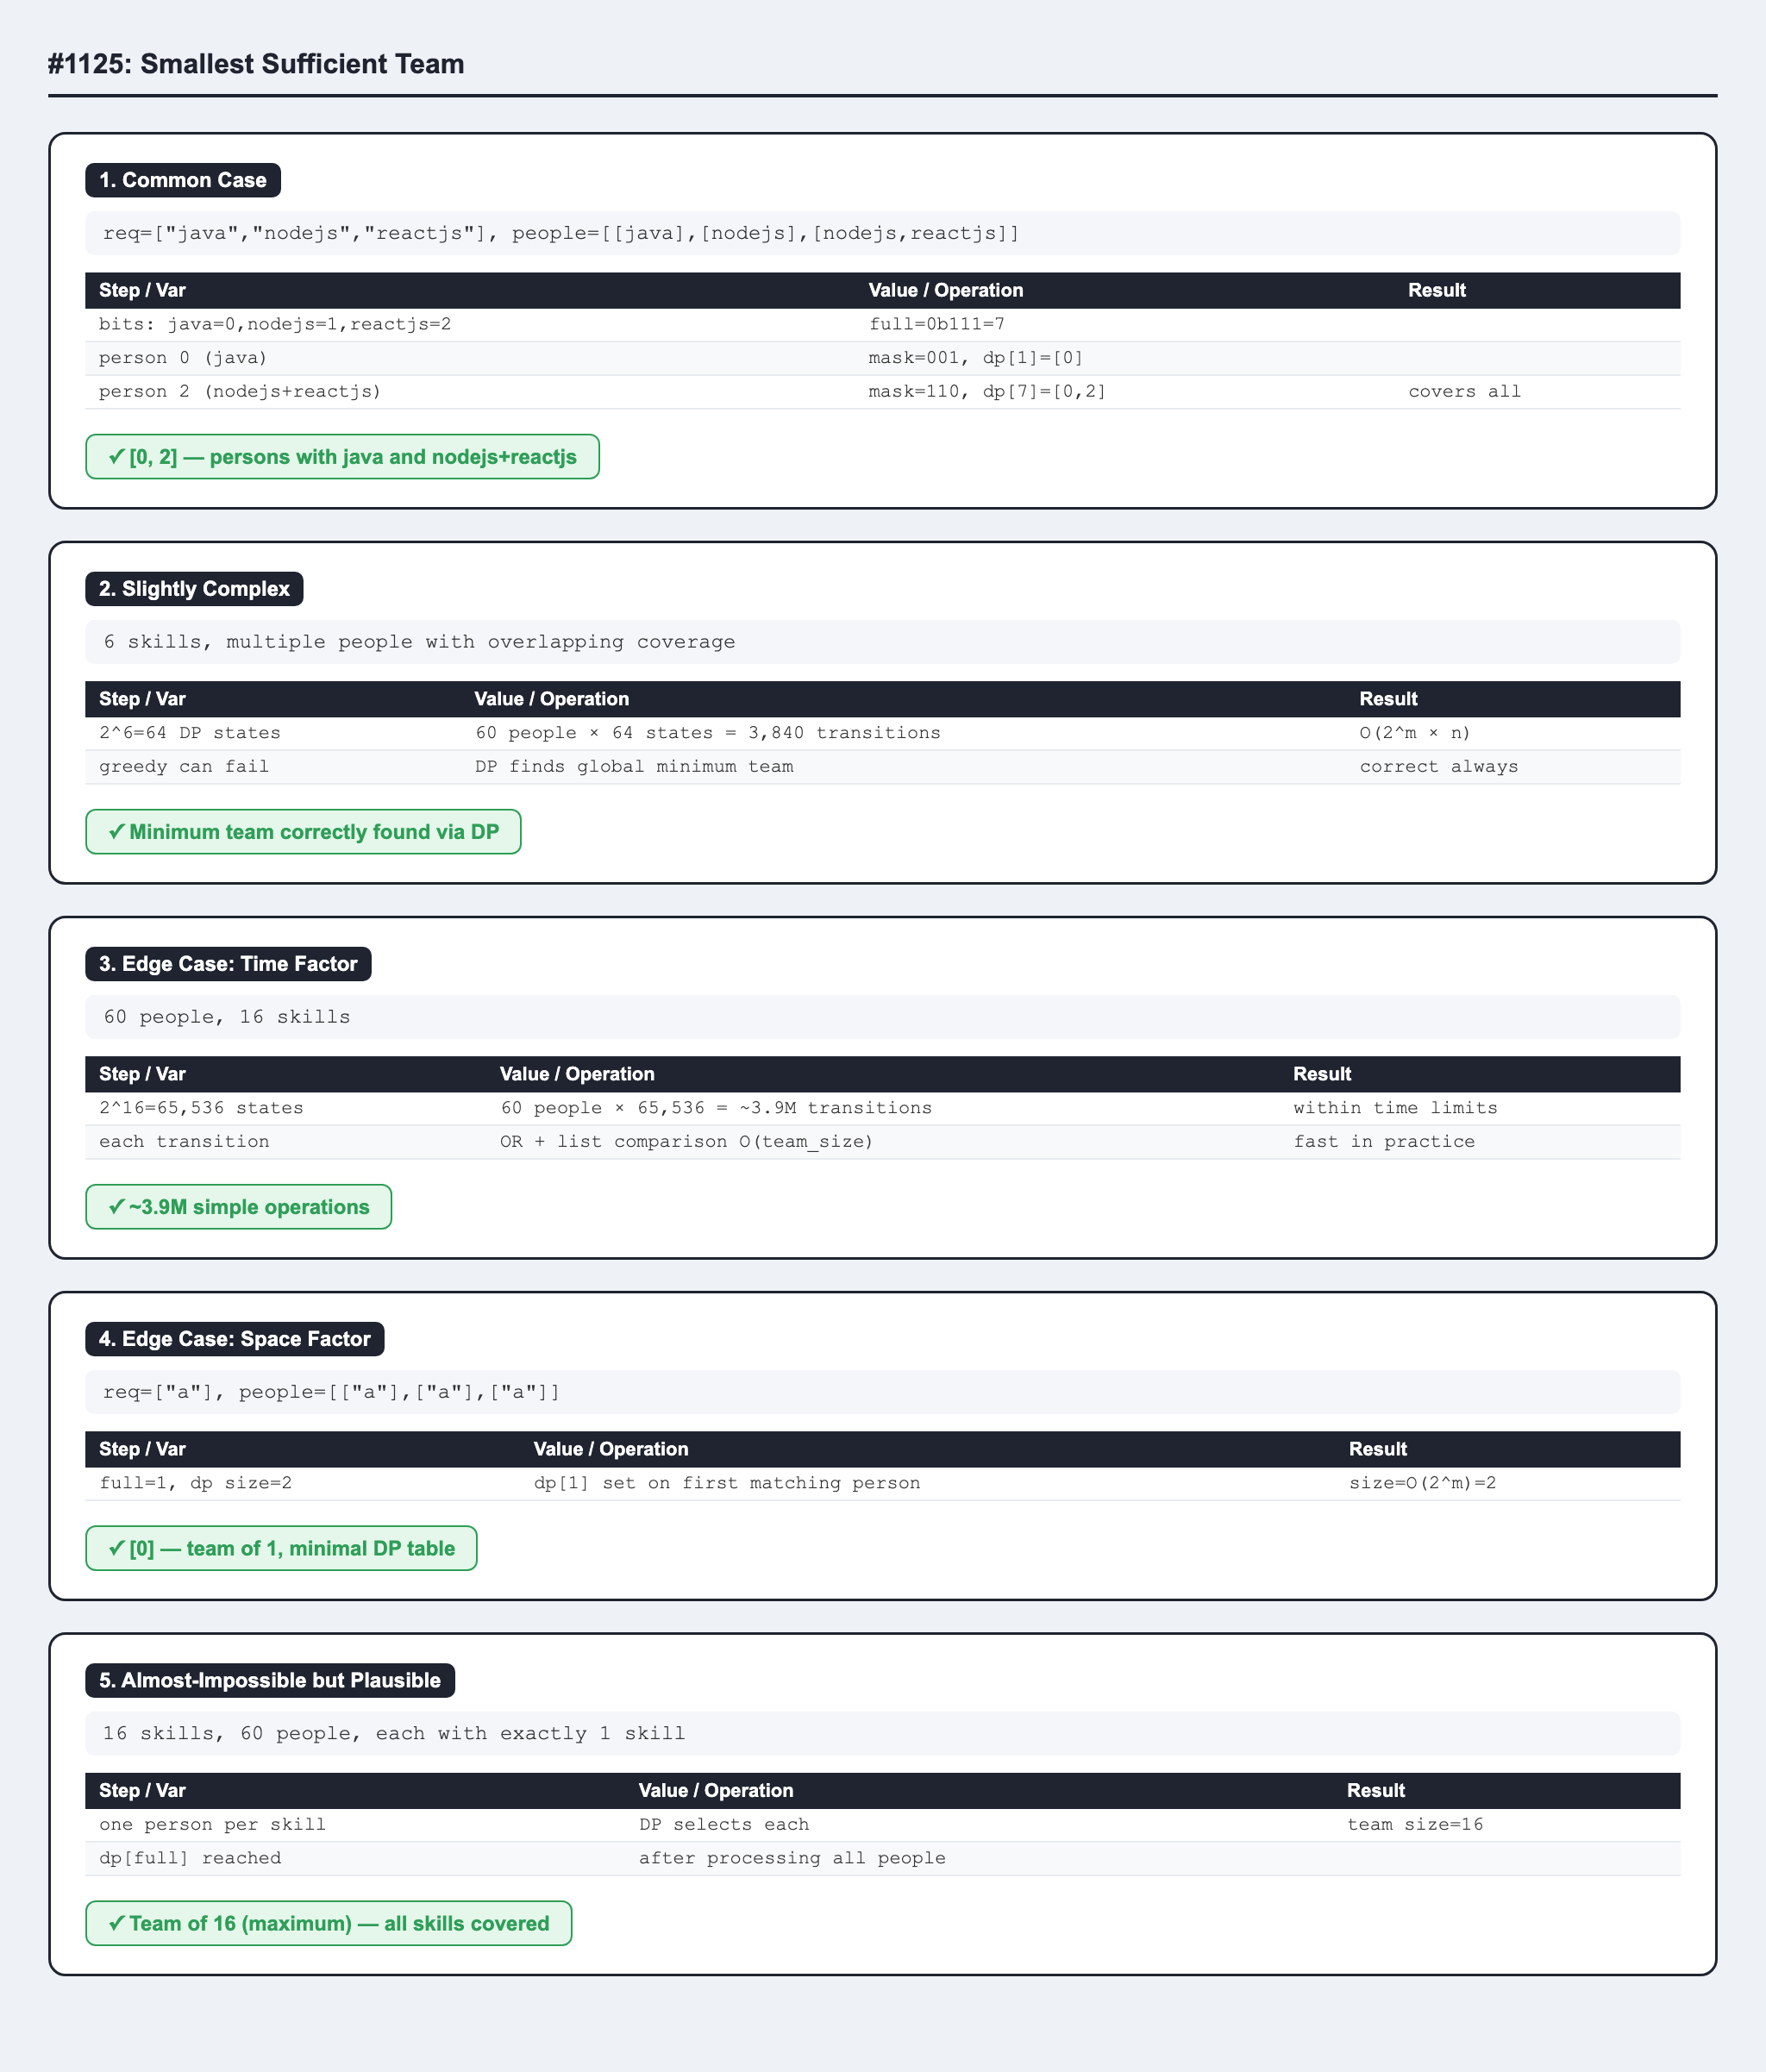